# IronClad Case Study 
# Task 3: Indexing selection (architecture design)

### Goal

We address the architecture-design questions:

**-How does retrieval performance change as we scale the number of gallery images?**

**-Which indexing strategy should we choose among Brute Force, HNSW, and LSH for a system that may eventually handle a billion images?**

The analysis proceeds in five stages. First, HNSW and LSH are tuned on the real IronClad workload (`efSearch` for HNSW, `nbits` for LSH) so that the subsequent comparison reflects each method's capabilities rather than arbitrary defaults. 

Second, all three strategies are benchmarked on the full IronClad gallery, measuring Top-1 and Top-5 accuracy, Recall@10 versus Brute Force, query latency, build time, and serialized index size. 

Third, the gallery is scaled within the real dataset through identity-preserving subsampling to observe how retrieval quality and latency evolve as the number of indexed images grows. 

Fourth, a synthetic benchmark with normalized 512-dimensional vectors at progressively larger sizes isolates the asymptotic scaling behavior of each index structure, since the real gallery is too small to expose billion-scale bottlenecks. 

Fifth, the synthetic measurements are extrapolated to $10^9$ vectors via power-law latency fits and linear memory scaling, producing projected deployment estimates. 

The notebook uses MTCNN-preprocessed embeddings throughout, so the comparison is focused entirely on the indexing layer.

In [1]:
import sys, subprocess, importlib, os, json, time, gc, math, textwrap
from pathlib import Path

import numpy as np
import pandas as pd

def _ensure(import_name: str, pip_name: str | None = None):
    pip_name = pip_name or import_name
    try:
        importlib.import_module(import_name)
        print(f"✓ {import_name} already installed")
    except Exception:
        print(f"Installing {pip_name} ...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", pip_name])
        importlib.import_module(import_name)
        print(f"✓ Installed {import_name}")

_ensure("faiss", "faiss-cpu")
_ensure("tqdm", "tqdm")
_ensure("facenet_pytorch", "facenet-pytorch")

import faiss
import torch
import matplotlib.pyplot as plt
from PIL import Image, UnidentifiedImageError
from tqdm.auto import tqdm

# Compatibility shim for some older checkpoint pickles.
import types
if "torch.utils.serialization" not in sys.modules:
    sys.modules["torch.utils.serialization"] = types.ModuleType("torch.utils.serialization")

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
np.random.seed(42)

print("CUDA available:", torch.cuda.is_available(), "| DEVICE:", DEVICE)


✓ faiss already installed
✓ tqdm already installed
✓ facenet_pytorch already installed
CUDA available: False | DEVICE: cpu


In [2]:
# Project imports
PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from ironclad.modules.extraction.preprocessing import Preprocessing
from ironclad.modules.extraction.embedding import Embedding
from ironclad.modules.retrieval.index.bruteforce import FaissBruteForce
from ironclad.modules.retrieval.index.hnsw import FaissHNSW
from ironclad.modules.retrieval.index.lsh import FaissLSH

print("Project root:", PROJECT_ROOT)

# Selected upstream design choices from earlier tasks
BEST_MODEL = "vggface2"
METRIC = "cosine"
EMBED_DIM = 512

# MTCNN is treated as the chosen preprocessing design
MTCNN_THRESHOLD = 0.80
MTCNN_MARGIN = 20

# ANN candidate grids
HNSW_EFSEARCH_CANDIDATES = [16, 32, 64, 128]
LSH_NBITS_CANDIDATES = [128, 256, 512]

# Synthetic scaling sizes used for the billion-scale argument
SYNTH_NS = (50_000, 200_000, 500_000)
TARGET_N_1B = 1_000_000_000


Project root: C:\Users\Usuario\Downloads\ironclad-hortner87-main(1)\ironclad-hortner87-main


## Load the IronClad gallery/probe split

Expected directory structure:

```text
BASE/
  ironclad/
    storage/
      gallery/<identity>/*
      probe/<identity>/*
```

We only use identities that appear in **both** gallery and probe.


In [3]:
STORAGE_ROOT = PROJECT_ROOT / "ironclad" / "storage"
GALLERY_DIR = STORAGE_ROOT / "gallery"
PROBE_DIR = STORAGE_ROOT / "probe"

if not (GALLERY_DIR.exists() and PROBE_DIR.exists()):
    raise FileNotFoundError(f"Expected {GALLERY_DIR} and {PROBE_DIR}")

def list_images_by_identity(base_dir: Path):
    exts = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}
    out = {}
    for ident_dir in sorted([p for p in base_dir.iterdir() if p.is_dir()]):
        imgs = []
        for p in ident_dir.rglob("*"):
            if not p.is_file():
                continue
            if p.suffix.lower() not in exts:
                continue
            if p.name.startswith("._") or p.name.startswith("."):
                continue
            imgs.append(p)
        if imgs:
            out[ident_dir.name] = sorted(imgs)
    return out

gallery = list_images_by_identity(GALLERY_DIR)
probe = list_images_by_identity(PROBE_DIR)
overlap = sorted(set(gallery.keys()) & set(probe.keys()))

gallery_paths, gallery_labels = [], []
for ident in overlap:
    for p in gallery[ident]:
        gallery_paths.append(p)
        gallery_labels.append(ident)

probe_paths, probe_labels = [], []
for ident in overlap:
    for p in probe[ident]:
        probe_paths.append(p)
        probe_labels.append(ident)

print("Gallery identities:", len(gallery))
print("Probe identities  :", len(probe))
print("Overlap identities:", len(overlap))
print("Gallery images    :", len(gallery_paths))
print("Probe images      :", len(probe_paths))


Gallery identities: 1000
Probe identities  : 999
Overlap identities: 999
Gallery images    : 2261
Probe images      : 999


## Compute MTCNN-preprocessed embeddings

In [4]:
preproc = Preprocessing(image_size=160)
CACHE_DIR = Path.cwd() / "cache_task2_final_mtcnn"
CACHE_DIR.mkdir(parents=True, exist_ok=True)

from facenet_pytorch import MTCNN

mtcnn = MTCNN(
    image_size=160,
    margin=MTCNN_MARGIN,
    keep_all=True,
    device=DEVICE,
)

def pil_load_rgb(path: Path):
    try:
        return Image.open(path).convert("RGB")
    except (UnidentifiedImageError, OSError):
        return None

DETECTION_CACHE_PATH = CACHE_DIR / "mtcnn_detection_cache.json"
if DETECTION_CACHE_PATH.exists():
    with open(DETECTION_CACHE_PATH, "r", encoding="utf-8") as f:
        DET_CACHE = json.load(f)
else:
    DET_CACHE = {}

def _save_det_cache():
    with open(DETECTION_CACHE_PATH, "w", encoding="utf-8") as f:
        json.dump(DET_CACHE, f)

def detect_best_face(path: Path):
    key = str(path)
    if key in DET_CACHE:
        rec = DET_CACHE[key]
        box = rec["box"]
        prob = rec["prob"]
        return (np.array(box, dtype=float) if box is not None else None), prob

    img = pil_load_rgb(path)
    if img is None:
        DET_CACHE[key] = {"box": None, "prob": None}
        _save_det_cache()
        return None, None

    boxes, probs = mtcnn.detect(img)
    if boxes is None or probs is None or len(boxes) == 0:
        DET_CACHE[key] = {"box": None, "prob": None}
        _save_det_cache()
        return None, None

    best = int(np.argmax(probs))
    box = boxes[best].tolist()
    prob = float(probs[best]) if probs[best] is not None else None
    DET_CACHE[key] = {"box": box, "prob": prob}
    _save_det_cache()
    return np.array(box, dtype=float), prob

def crop_from_box(img: Image.Image, box, margin_px=MTCNN_MARGIN):
    x1, y1, x2, y2 = [float(v) for v in box]
    x1 = max(0, int(np.floor(x1)) - margin_px)
    y1 = max(0, int(np.floor(y1)) - margin_px)
    x2 = min(img.width, int(np.ceil(x2)) + margin_px)
    y2 = min(img.height, int(np.ceil(y2)) + margin_px)
    if x2 <= x1 or y2 <= y1:
        return img
    return img.crop((x1, y1, x2, y2))

def get_mtcnn_image(path: Path, threshold: float = MTCNN_THRESHOLD):
    img = pil_load_rgb(path)
    if img is None:
        return None, None, False

    box, prob = detect_best_face(path)
    use_crop = box is not None and prob is not None and prob >= threshold
    if use_crop:
        return crop_from_box(img, box, margin_px=MTCNN_MARGIN), prob, True
    return img, prob, False

def l2_normalize(X: np.ndarray, eps: float = 1e-12) -> np.ndarray:
    X = np.asarray(X, dtype=np.float32)
    norms = np.linalg.norm(X, axis=1, keepdims=True)
    return X / np.maximum(norms, eps)

def embed_dataset_mtcnn(model_name: str, paths, labels, split_name: str, threshold: float = MTCNN_THRESHOLD):
    key_src = f"{model_name}|{split_name}|mtcnn|{threshold}|{len(paths)}"
    key = str(abs(hash(key_src)))
    cache_path = CACHE_DIR / f"emb_{model_name}_{split_name}_mtcnn_{key}.npz"

    if cache_path.exists():
        z = np.load(cache_path, allow_pickle=True)
        stats = {
            "crop_rate": float(z["crop_rate"][0]),
            "mean_conf": float(z["mean_conf"][0]) if len(z["mean_conf"]) else np.nan,
            "n_images": int(z["n_images"][0]),
        }
        X = z["X"].astype(np.float32)
        X = l2_normalize(X)
        return X, z["labels"].tolist(), [Path(p) for p in z["paths"].tolist()], stats

    model = Embedding(pretrained=model_name, device=DEVICE)
    vecs, labs, keep_paths = [], [], []
    confs, used_crop = [], []

    for p, lab in tqdm(list(zip(paths, labels)), desc=f"Embedding {split_name} | {model_name} | mtcnn"):
        img_mtcnn, conf, did_crop = get_mtcnn_image(p, threshold=threshold)
        if img_mtcnn is None:
            continue
        tens = preproc.process(img_mtcnn)
        v = model.encode(tens).astype(np.float32)
        vecs.append(v.reshape(1, -1))
        labs.append(lab)
        keep_paths.append(str(p))
        if conf is not None:
            confs.append(float(conf))
        used_crop.append(bool(did_crop))

    if not vecs:
        raise RuntimeError(f"No embeddings were produced for split={split_name}")

    X = np.vstack(vecs).astype(np.float32)
    stats = {
        "crop_rate": float(np.mean(used_crop)) if used_crop else 0.0,
        "mean_conf": float(np.mean(confs)) if confs else np.nan,
        "n_images": int(len(keep_paths)),
    }

    np.savez(
        cache_path,
        X=X,
        labels=np.array(labs, dtype=object),
        paths=np.array(keep_paths, dtype=object),
        crop_rate=np.array([stats["crop_rate"]], dtype=np.float32),
        mean_conf=np.array([stats["mean_conf"]], dtype=np.float32),
        n_images=np.array([stats["n_images"]], dtype=np.int32),
    )

    X = l2_normalize(X)
    return X, labs, [Path(p) for p in keep_paths], stats

gal_X, gal_y, gal_p, gal_stats = embed_dataset_mtcnn(BEST_MODEL, gallery_paths, gallery_labels, "gallery")
prb_X, prb_y, prb_p, prb_stats = embed_dataset_mtcnn(BEST_MODEL, probe_paths, probe_labels, "probe")

print("Gallery embeddings:", gal_X.shape, gal_stats)
print("Probe embeddings  :", prb_X.shape, prb_stats)


Embedding gallery | vggface2 | mtcnn:   0%|          | 0/2261 [00:00<?, ?it/s]

Embedding probe | vggface2 | mtcnn:   0%|          | 0/999 [00:00<?, ?it/s]

Gallery embeddings: (2261, 512) {'crop_rate': 0.9995577178239717, 'mean_conf': 0.9996893697871571, 'n_images': 2261}
Probe embeddings  : (999, 512) {'crop_rate': 1.0, 'mean_conf': 0.9995434910088807, 'n_images': 999}


## Evaluation helpers

We evaluate each index with:

- **Top-1 accuracy** and **Top-5 accuracy** on the real identification task
- **Recall@10 vs Brute Force** as an ANN quality check
- **ms/query**
- **build time**
- **serialized bytes / bytes per vector**

For cosine similarity, we use L2-normalized embeddings throughout.


In [5]:
def serialized_size_bytes(index) -> int:
    return len(faiss.serialize_index(index))

def build_index(index_type: str,
                X: np.ndarray,
                metadata,
                metric: str = "cosine",
                hnsw_M: int = 32,
                hnsw_efC: int = 40,
                hnsw_efSearch: int = 64,
                lsh_nbits: int = 256):
    t0 = time.perf_counter()

    if index_type == "bruteforce":
        idx = FaissBruteForce(dim=X.shape[1], metric=metric)
        idx.add_embeddings(X, metadata)

    elif index_type == "hnsw":
        idx = FaissHNSW(dim=X.shape[1], metric=metric, M=hnsw_M, efConstruction=hnsw_efC)
        idx.add_embeddings(X, metadata)
        idx.index.hnsw.efSearch = int(hnsw_efSearch)

    elif index_type == "lsh":
        idx = FaissLSH(dim=X.shape[1], nbits=lsh_nbits)
        idx.add_embeddings(X, metadata)

    else:
        raise ValueError(f"Unknown index_type={index_type}")

    t1 = time.perf_counter()
    return idx, (t1 - t0)

def neighbors_to_topk_identity(indices, metadata, k_id: int = 5):
    out = []
    seen = set()
    for idx in indices:
        j = int(idx)
        if j < 0 or j >= len(metadata):
            continue
        ident = metadata[j]
        if ident in seen:
            continue
        seen.add(ident)
        out.append(ident)
        if len(out) >= k_id:
            break
    return out

def evaluate_index(idx, Q, true_labels, k_neighbors: int = 10, topk_id=(1, 5)):
    t0 = time.perf_counter()
    D, I = idx.index.search(Q.astype(np.float32), k_neighbors)
    t1 = time.perf_counter()

    metrics = {
        "ms_per_query": (t1 - t0) * 1000.0 / Q.shape[0]
    }

    for kid in topk_id:
        correct = 0
        for qi in range(Q.shape[0]):
            ranked_ids = neighbors_to_topk_identity(I[qi], idx.metadata, k_id=kid)
            if true_labels[qi] in ranked_ids:
                correct += 1
        metrics[f"top{kid}_accuracy"] = correct / Q.shape[0] if Q.shape[0] else np.nan

    return metrics, (D, I)

def recall_at_k(approx_i: np.ndarray, exact_i: np.ndarray, k: int = 10) -> float:
    hits = 0
    for qi in range(exact_i.shape[0]):
        target = set(map(int, exact_i[qi, :k]))
        got = set(map(int, approx_i[qi, :k]))
        if len(target & got) > 0:
            hits += 1
    return hits / exact_i.shape[0]

def time_it(fn, *args, **kwargs):
    t0 = time.perf_counter()
    out = fn(*args, **kwargs)
    t1 = time.perf_counter()
    return out, (t1 - t0)


## Part 1: Tune ANN hyperparameters on a subset of the IronClad dataset

Since Brute Force has no ANN hyperparameters, we use it as the exact reference.

Then we tune:

- **HNSW**: `efSearch`
- **LSH**: `nbits`

Selection rule:

1. maximize **Top-1 accuracy**
2. break ties with **higher Recall@10 vs Brute Force**
3. break remaining ties with **lower latency**

In [6]:
# Exact reference on the full real gallery.
bf_ref, _ = build_index("bruteforce", gal_X, gal_y, metric=METRIC)
bf_ref_metrics, (_, bf_ref_I) = evaluate_index(bf_ref, prb_X, prb_y, k_neighbors=10, topk_id=(1, 5))

print("Brute Force reference metrics:")
print(bf_ref_metrics)


Brute Force reference metrics:
{'ms_per_query': 0.013232532531568161, 'top1_accuracy': 0.8428428428428428, 'top5_accuracy': 0.9039039039039038}


In [7]:
rows = []

for ef in HNSW_EFSEARCH_CANDIDATES:
    idx, build_s = build_index(
        "hnsw",
        gal_X,
        gal_y,
        metric=METRIC,
        hnsw_M=32,
        hnsw_efC=40,
        hnsw_efSearch=ef,
    )
    metrics, (_, I) = evaluate_index(idx, prb_X, prb_y, k_neighbors=10, topk_id=(1, 5))
    rows.append({
        "index": "hnsw",
        "setting_name": "efSearch",
        "setting_value": ef,
        "build_s": build_s,
        "top1_accuracy": metrics["top1_accuracy"],
        "top5_accuracy": metrics["top5_accuracy"],
        "recall10_vs_bf": recall_at_k(I, bf_ref_I, k=10),
        "ms_per_query": metrics["ms_per_query"],
    })

for nbits in LSH_NBITS_CANDIDATES:
    idx, build_s = build_index(
        "lsh",
        gal_X,
        gal_y,
        metric=METRIC,
        lsh_nbits=nbits,
    )
    metrics, (_, I) = evaluate_index(idx, prb_X, prb_y, k_neighbors=10, topk_id=(1, 5))
    rows.append({
        "index": "lsh",
        "setting_name": "nbits",
        "setting_value": nbits,
        "build_s": build_s,
        "top1_accuracy": metrics["top1_accuracy"],
        "top5_accuracy": metrics["top5_accuracy"],
        "recall10_vs_bf": recall_at_k(I, bf_ref_I, k=10),
        "ms_per_query": metrics["ms_per_query"],
    })

tune_df = pd.DataFrame(rows)
tune_df = tune_df.sort_values(
    ["index", "top1_accuracy", "recall10_vs_bf", "ms_per_query"],
    ascending=[True, False, False, True],
).reset_index(drop=True)

tune_df


,index,setting_name,setting_value,build_s,top1_accuracy,top5_accuracy,recall10_vs_bf,ms_per_query
0,hnsw,efSearch,16,0.050964,0.842843,0.903904,1.000000,0.009419
1,hnsw,efSearch,64,0.047795,0.842843,0.903904,1.000000,0.023156
2,hnsw,efSearch,128,0.050120,0.842843,0.903904,1.000000,0.037816
3,hnsw,efSearch,32,0.050769,0.841842,0.902903,1.000000,0.011427
4,lsh,nbits,512,0.050982,0.803804,0.896897,1.000000,0.005990
5,lsh,nbits,256,0.042843,0.778779,0.875876,1.000000,0.004484
6,lsh,nbits,128,0.029738,0.686687,0.829830,0.994995,0.002761


In [8]:
def choose_setting(df_sub: pd.DataFrame, index_name: str) -> int:
    sub = df_sub[df_sub["index"] == index_name].sort_values(
        ["top1_accuracy", "recall10_vs_bf", "ms_per_query"],
        ascending=[False, False, True],
    )
    return int(sub.iloc[0]["setting_value"])

BEST_EFSEARCH = choose_setting(tune_df, "hnsw")
BEST_NBITS = choose_setting(tune_df, "lsh")

chosen_settings_df = pd.DataFrame([
    {"index": "hnsw", "setting_name": "efSearch", "setting_value": BEST_EFSEARCH},
    {"index": "lsh", "setting_name": "nbits", "setting_value": BEST_NBITS},
])

chosen_settings_df


,index,setting_name,setting_value
0,hnsw,efSearch,16
1,lsh,nbits,512


## Part 2: Compare Brute Force, HNSW, and LSH on the full IronClad dataset

This is the main end-to-end architecture comparison using the full dataset.

In [9]:
rows = []

# Brute Force
idx_bf, build_bf = build_index("bruteforce", gal_X, gal_y, metric=METRIC)
m_bf, (_, I_bf) = evaluate_index(idx_bf, prb_X, prb_y, k_neighbors=10, topk_id=(1, 5))
rows.append({
    "index": "bruteforce",
    "build_s": build_bf,
    "top1_accuracy": m_bf["top1_accuracy"],
    "top5_accuracy": m_bf["top5_accuracy"],
    "recall10_vs_bf": 1.0,
    "ms_per_query": m_bf["ms_per_query"],
    "serialized_bytes": serialized_size_bytes(idx_bf.index),
})

# HNSW
idx_h, build_h = build_index(
    "hnsw",
    gal_X,
    gal_y,
    metric=METRIC,
    hnsw_M=32,
    hnsw_efC=40,
    hnsw_efSearch=BEST_EFSEARCH,
)
m_h, (_, I_h) = evaluate_index(idx_h, prb_X, prb_y, k_neighbors=10, topk_id=(1, 5))
rows.append({
    "index": "hnsw",
    "build_s": build_h,
    "top1_accuracy": m_h["top1_accuracy"],
    "top5_accuracy": m_h["top5_accuracy"],
    "recall10_vs_bf": recall_at_k(I_h, I_bf, 10),
    "ms_per_query": m_h["ms_per_query"],
    "serialized_bytes": serialized_size_bytes(idx_h.index),
})

# LSH
idx_l, build_l = build_index(
    "lsh",
    gal_X,
    gal_y,
    metric=METRIC,
    lsh_nbits=BEST_NBITS,
)
m_l, (_, I_l) = evaluate_index(idx_l, prb_X, prb_y, k_neighbors=10, topk_id=(1, 5))
rows.append({
    "index": "lsh",
    "build_s": build_l,
    "top1_accuracy": m_l["top1_accuracy"],
    "top5_accuracy": m_l["top5_accuracy"],
    "recall10_vs_bf": recall_at_k(I_l, I_bf, 10),
    "ms_per_query": m_l["ms_per_query"],
    "serialized_bytes": serialized_size_bytes(idx_l.index),
})

real_full_df = pd.DataFrame(rows)
real_full_df["bytes_per_vec"] = real_full_df["serialized_bytes"] / gal_X.shape[0]
real_full_df = real_full_df.sort_values("index").reset_index(drop=True)
real_full_df


,index,build_s,top1_accuracy,top5_accuracy,recall10_vs_bf,ms_per_query,serialized_bytes,bytes_per_vec
0,bruteforce,0.011445,0.842843,0.903904,1.0,0.012351,4630573,2048.019903
1,hnsw,0.044613,0.841842,0.902903,1.0,0.007745,5244766,2319.666519
2,lsh,0.055216,0.803804,0.896897,1.0,0.007660,1193373,527.807607


## Part 3: Real-data scaling experiment

The real-task question is not only "which index is best now?" but also: **How do retrieval quality and latency change as the gallery grows?**

To make this fair, we vary the gallery size while keeping at least one image per identity, so the closed-set identification setup remains valid.

In [10]:
def make_real_gallery_subset_indices(labels, n_target: int, seed: int = 42):
    """
    Return gallery indices for a subset that keeps at least one image per identity.
    """
    rng = np.random.default_rng(seed)
    by_id = {}
    for i, lab in enumerate(labels):
        by_id.setdefault(lab, []).append(i)

    anchors = [int(rng.choice(by_id[lab])) for lab in sorted(by_id.keys())]
    anchor_set = set(anchors)

    if n_target <= len(anchors):
        return np.array(anchors[:n_target], dtype=int)

    remaining = [i for i in range(len(labels)) if i not in anchor_set]
    n_extra = min(n_target - len(anchors), len(remaining))
    extra = rng.choice(remaining, size=n_extra, replace=False).tolist() if n_extra > 0 else []

    return np.array(anchors + extra, dtype=int)

n_min = len(set(gal_y))
n_full = len(gal_y)

TARGET_NS_REAL = sorted(set([
    n_min,
    int(0.25 * n_full),
    int(0.50 * n_full),
    int(0.75 * n_full),
    n_full,
]))
TARGET_NS_REAL


[565, 999, 1130, 1695, 2261]

In [11]:
rows = []

for N in tqdm(TARGET_NS_REAL, desc="Real-data scaling"):
    sel = make_real_gallery_subset_indices(gal_y, N, seed=42)
    Xg = gal_X[sel]
    yg = [gal_y[i] for i in sel]

    # Brute Force
    idx_bf_s, build_bf_s = build_index("bruteforce", Xg, yg, metric=METRIC)
    m_bf_s, (_, I_bf_s) = evaluate_index(idx_bf_s, prb_X, prb_y, k_neighbors=10, topk_id=(1, 5))
    rows.append({
        "index": "bruteforce",
        "N_gallery": N,
        "build_s": build_bf_s,
        "top1_accuracy": m_bf_s["top1_accuracy"],
        "top5_accuracy": m_bf_s["top5_accuracy"],
        "recall10_vs_bf": 1.0,
        "ms_per_query": m_bf_s["ms_per_query"],
    })

    # HNSW
    idx_h_s, build_h_s = build_index(
        "hnsw",
        Xg,
        yg,
        metric=METRIC,
        hnsw_M=32,
        hnsw_efC=40,
        hnsw_efSearch=BEST_EFSEARCH,
    )
    m_h_s, (_, I_h_s) = evaluate_index(idx_h_s, prb_X, prb_y, k_neighbors=10, topk_id=(1, 5))
    rows.append({
        "index": "hnsw",
        "N_gallery": N,
        "build_s": build_h_s,
        "top1_accuracy": m_h_s["top1_accuracy"],
        "top5_accuracy": m_h_s["top5_accuracy"],
        "recall10_vs_bf": recall_at_k(I_h_s, I_bf_s, 10),
        "ms_per_query": m_h_s["ms_per_query"],
    })

    # LSH
    idx_l_s, build_l_s = build_index(
        "lsh",
        Xg,
        yg,
        metric=METRIC,
        lsh_nbits=BEST_NBITS,
    )
    m_l_s, (_, I_l_s) = evaluate_index(idx_l_s, prb_X, prb_y, k_neighbors=10, topk_id=(1, 5))
    rows.append({
        "index": "lsh",
        "N_gallery": N,
        "build_s": build_l_s,
        "top1_accuracy": m_l_s["top1_accuracy"],
        "top5_accuracy": m_l_s["top5_accuracy"],
        "recall10_vs_bf": recall_at_k(I_l_s, I_bf_s, 10),
        "ms_per_query": m_l_s["ms_per_query"],
    })

real_scale_df = pd.DataFrame(rows)
real_scale_df


Real-data scaling:   0%|          | 0/5 [00:00<?, ?it/s]

,index,N_gallery,build_s,top1_accuracy,top5_accuracy,recall10_vs_bf,ms_per_query
0,bruteforce,565,0.002557,0.469469,0.515516,1.0,0.005022
1,hnsw,565,0.009054,0.469469,0.515516,1.0,0.005364
2,lsh,565,0.050936,0.457457,0.506507,1.0,0.005111
3,bruteforce,999,0.005070,0.813814,0.898899,1.0,0.006139
4,hnsw,999,0.018134,0.813814,0.898899,1.0,0.006000
5,lsh,999,0.053711,0.783784,0.886887,1.0,0.005142
6,bruteforce,1130,0.005520,0.823824,0.905906,1.0,0.007865
7,hnsw,1130,0.019160,0.824825,0.905906,1.0,0.005070
8,lsh,1130,0.050175,0.792793,0.892893,1.0,0.006376
9,bruteforce,1695,0.008624,0.838839,0.906907,1.0,0.010209


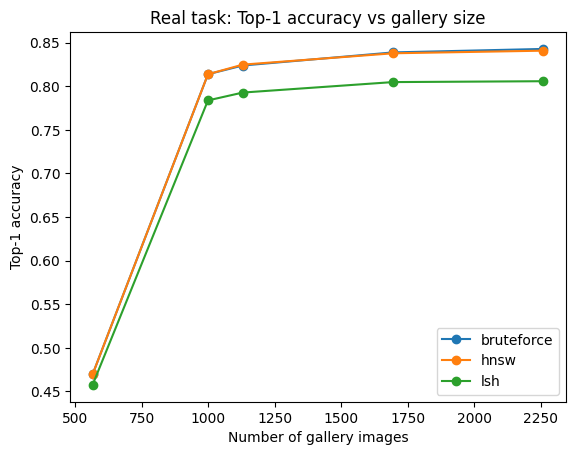

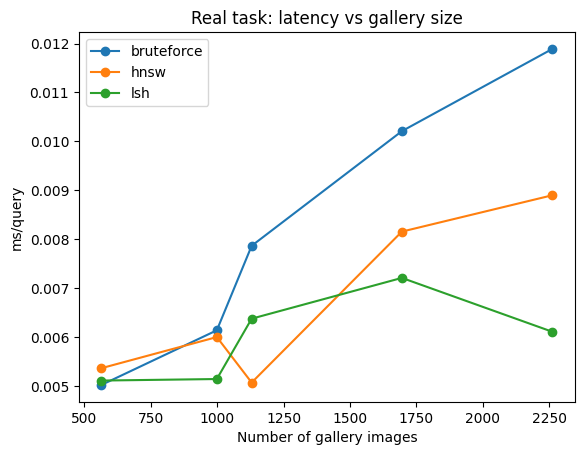

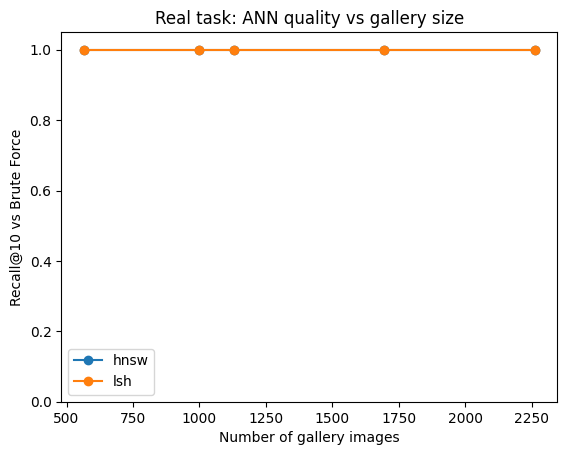

In [12]:
plt.figure()
for idx_name in real_scale_df["index"].unique():
    sub = real_scale_df[real_scale_df["index"] == idx_name].sort_values("N_gallery")
    plt.plot(sub["N_gallery"], sub["top1_accuracy"], marker="o", label=idx_name)
plt.xlabel("Number of gallery images")
plt.ylabel("Top-1 accuracy")
plt.title("Real task: Top-1 accuracy vs gallery size")
plt.legend()
plt.show()

plt.figure()
for idx_name in real_scale_df["index"].unique():
    sub = real_scale_df[real_scale_df["index"] == idx_name].sort_values("N_gallery")
    plt.plot(sub["N_gallery"], sub["ms_per_query"], marker="o", label=idx_name)
plt.xlabel("Number of gallery images")
plt.ylabel("ms/query")
plt.title("Real task: latency vs gallery size")
plt.legend()
plt.show()

plt.figure()
for idx_name in ["hnsw", "lsh"]:
    sub = real_scale_df[real_scale_df["index"] == idx_name].sort_values("N_gallery")
    plt.plot(sub["N_gallery"], sub["recall10_vs_bf"], marker="o", label=idx_name)
plt.xlabel("Number of gallery images")
plt.ylabel("Recall@10 vs Brute Force")
plt.title("Real task: ANN quality vs gallery size")
plt.ylim(0, 1.05)
plt.legend()
plt.show()


## Part 4: Synthetic scalability benchmark for the billion-scale requirement

The real IronClad dataset is too small to directly justify scaling behavior at 1B.

So we retain a synthetic benchmark that isolates the scaling behavior of the index structures themselves:

- Brute Force
- HNSW
- LSH

using the same embedding dimensionality and the same chosen ANN settings.


In [13]:
def run_synthetic_benchmark(Ns=SYNTH_NS, d=EMBED_DIM, nq=200, k=10):
    rows = []

    for N in Ns:
        print(f"\n=== Synthetic benchmark N={N:,} ===")

        X = np.random.random((N, d)).astype(np.float32)
        Q = np.random.random((nq, d)).astype(np.float32)
        X = l2_normalize(X)
        Q = l2_normalize(Q)
        metadata = [str(i) for i in range(N)]

        # Brute Force
        bf, t_bf = build_index("bruteforce", X, metadata, metric=METRIC)
        (_, t_qbf) = time_it(bf.index.search, Q, k)
        _, I_bf_syn = bf.index.search(Q, k)
        rows.append({
            "index": "bruteforce",
            "N": N,
            "build_s": t_bf,
            "ms_per_query": t_qbf * 1000.0 / nq,
            "recall10_vs_bf": 1.0,
            "serialized_bytes": serialized_size_bytes(bf.index),
        })

        # HNSW
        h, t_h = build_index(
            "hnsw",
            X,
            metadata,
            metric=METRIC,
            hnsw_M=32,
            hnsw_efC=40,
            hnsw_efSearch=BEST_EFSEARCH,
        )
        (_, t_qh) = time_it(h.index.search, Q, k)
        _, I_h_syn = h.index.search(Q, k)
        rows.append({
            "index": "hnsw",
            "N": N,
            "build_s": t_h,
            "ms_per_query": t_qh * 1000.0 / nq,
            "recall10_vs_bf": recall_at_k(I_h_syn, I_bf_syn, k),
            "serialized_bytes": serialized_size_bytes(h.index),
        })

        # LSH
        l, t_l = build_index(
            "lsh",
            X,
            metadata,
            metric=METRIC,
            lsh_nbits=BEST_NBITS,
        )
        (_, t_ql) = time_it(l.index.search, Q, k)
        _, I_l_syn = l.index.search(Q, k)
        rows.append({
            "index": "lsh",
            "N": N,
            "build_s": t_l,
            "ms_per_query": t_ql * 1000.0 / nq,
            "recall10_vs_bf": recall_at_k(I_l_syn, I_bf_syn, k),
            "serialized_bytes": serialized_size_bytes(l.index),
        })

        del X, Q, bf, h, l, I_bf_syn, I_h_syn, I_l_syn
        gc.collect()

    df = pd.DataFrame(rows)
    df["bytes_per_vec"] = df["serialized_bytes"] / df["N"]
    return df

synth_df = run_synthetic_benchmark()
synth_df



=== Synthetic benchmark N=50,000 ===

=== Synthetic benchmark N=200,000 ===

=== Synthetic benchmark N=500,000 ===


,index,N,build_s,ms_per_query,recall10_vs_bf,serialized_bytes,bytes_per_vec
0,bruteforce,50000,0.270195,0.364892,1.000,102400045,2048.000900
1,hnsw,50000,32.214414,0.129997,0.880,116012578,2320.251560
2,lsh,50000,0.214312,0.051772,0.160,4248669,84.973380
3,bruteforce,200000,0.852540,1.284394,1.000,409600045,2048.000225
4,hnsw,200000,144.274452,0.158033,0.670,464028130,2320.140650
5,lsh,200000,0.499290,0.197967,0.030,13848669,69.243345
6,bruteforce,500000,2.119815,2.987972,1.000,1024000045,2048.000090
7,hnsw,500000,396.487174,0.160152,0.490,1160066018,2320.132036
8,lsh,500000,1.167255,0.416025,0.055,33048669,66.097338


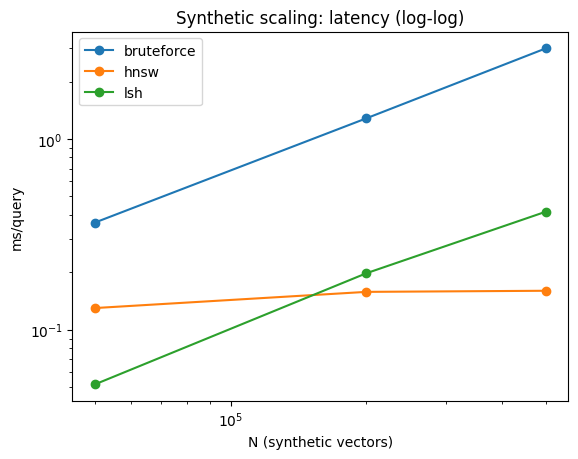

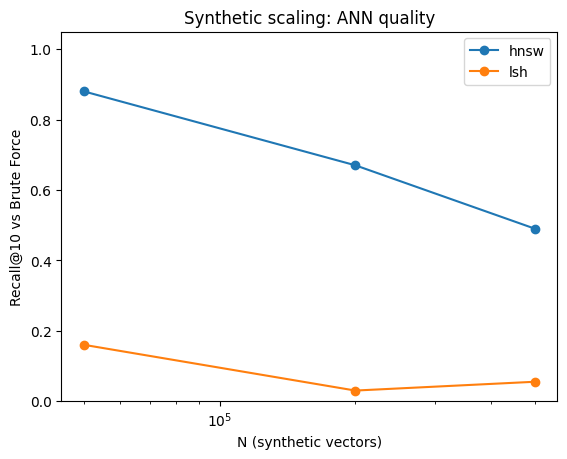

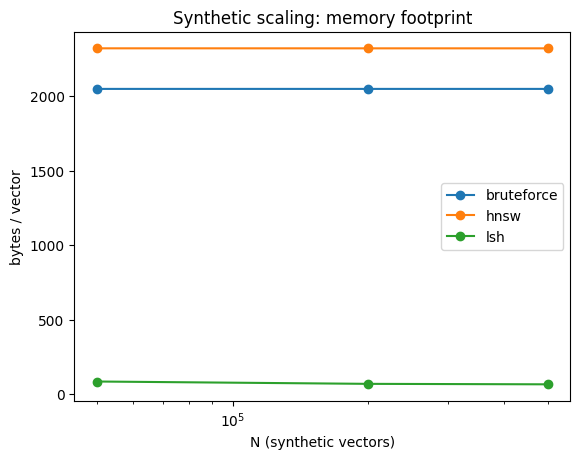

In [14]:
plt.figure()
for idx_name in synth_df["index"].unique():
    sub = synth_df[synth_df["index"] == idx_name].sort_values("N")
    plt.plot(sub["N"], sub["ms_per_query"], marker="o", label=idx_name)
plt.xscale("log")
plt.yscale("log")
plt.xlabel("N (synthetic vectors)")
plt.ylabel("ms/query")
plt.title("Synthetic scaling: latency (log-log)")
plt.legend()
plt.show()

plt.figure()
for idx_name in ["hnsw", "lsh"]:
    sub = synth_df[synth_df["index"] == idx_name].sort_values("N")
    plt.plot(sub["N"], sub["recall10_vs_bf"], marker="o", label=idx_name)
plt.xscale("log")
plt.xlabel("N (synthetic vectors)")
plt.ylabel("Recall@10 vs Brute Force")
plt.title("Synthetic scaling: ANN quality")
plt.ylim(0, 1.05)
plt.legend()
plt.show()

plt.figure()
for idx_name in synth_df["index"].unique():
    sub = synth_df[synth_df["index"] == idx_name].sort_values("N")
    plt.plot(sub["N"], sub["bytes_per_vec"], marker="o", label=idx_name)
plt.xscale("log")
plt.xlabel("N (synthetic vectors)")
plt.ylabel("bytes / vector")
plt.title("Synthetic scaling: memory footprint")
plt.legend()
plt.show()


## Part 5: Extrapolate to **1 billion vectors**

We estimate:

- **memory for 1B vectors** using measured bytes/vector
- **latency at 1B** by fitting a power law on the synthetic latency curve

This is not a claim of exact production latency. It is a scaling estimate used to compare the relative architecture risk of Brute Force, HNSW, and LSH at billion scale.


In [15]:
def fit_power_law(N, y):
    x = np.log(np.asarray(N, dtype=float))
    yy = np.log(np.asarray(y, dtype=float))
    b, loga = np.polyfit(x, yy, 1)
    return float(np.exp(loga)), float(b)

rows = []
for idx_name in synth_df["index"].unique():
    sub = synth_df[synth_df["index"] == idx_name].sort_values("N")

    bytes_per_vec_est = float(sub.iloc[-1]["bytes_per_vec"])
    mem_gb = bytes_per_vec_est * TARGET_N_1B / (1024 ** 3)

    a, b = fit_power_law(sub["N"], sub["ms_per_query"])
    ms_1b = a * (TARGET_N_1B ** b)

    rows.append({
        "index": idx_name,
        "bytes_per_vec_est": bytes_per_vec_est,
        "mem_for_1B_GB_est": mem_gb,
        "latency_fit_b": b,
        "ms_per_query_at_1B_est": ms_1b,
        "recall10_at_largest_N": float(sub.iloc[-1]["recall10_vs_bf"]),
    })

scale_df = pd.DataFrame(rows).sort_values("ms_per_query_at_1B_est").reset_index(drop=True)
scale_df


,index,bytes_per_vec_est,mem_for_1B_GB_est,latency_fit_b,ms_per_query_at_1B_est,recall10_at_largest_N
0,hnsw,2320.132036,2160.791341,0.094662,0.338061,0.490
1,lsh,66.097338,61.557943,0.910074,434.702185,0.055
2,bruteforce,2048.000090,1907.348717,0.912773,3070.222927,1.000


## Part 6: Final design summary

The final decision should be based on:

1. **real-task retrieval quality**
2. **large-scale systems behavior**

A good production choice is the index that:

- stays very close to Brute Force on Top-1 / Top-5
- is materially faster than Brute Force as the gallery grows
- has plausible memory / latency behavior at 1B


In [16]:
summary_df = (
    real_full_df[[
        "index",
        "top1_accuracy",
        "top5_accuracy",
        "recall10_vs_bf",
        "ms_per_query",
        "build_s",
        "bytes_per_vec",
    ]]
    .merge(
        scale_df[[
            "index",
            "mem_for_1B_GB_est",
            "ms_per_query_at_1B_est",
            "recall10_at_largest_N",
        ]],
        on="index",
        how="left",
    )
    .sort_values("index")
    .reset_index(drop=True)
)

summary_df


,index,top1_accuracy,top5_accuracy,recall10_vs_bf,ms_per_query,build_s,bytes_per_vec,mem_for_1B_GB_est,ms_per_query_at_1B_est,recall10_at_largest_N
0,bruteforce,0.842843,0.903904,1.0,0.012351,0.011445,2048.019903,1907.348717,3070.222927,1.000
1,hnsw,0.841842,0.902903,1.0,0.007745,0.044613,2319.666519,2160.791341,0.338061,0.490
2,lsh,0.803804,0.896897,1.0,0.007660,0.055216,527.807607,61.557943,434.702185,0.055


In [17]:
def recommend_index(real_df: pd.DataFrame, scale_df: pd.DataFrame, top1_tolerance: float = 0.01):
    real = real_df.copy()
    scale = scale_df.copy()

    bf_top1 = float(real.loc[real["index"] == "bruteforce", "top1_accuracy"].iloc[0])

    merged = real.merge(
        scale[["index", "ms_per_query_at_1B_est", "mem_for_1B_GB_est"]],
        on="index",
        how="left",
    )

    # Keep methods that are close enough to exact accuracy.
    near_exact = merged[merged["top1_accuracy"] >= (bf_top1 - top1_tolerance)].copy()
    candidate_pool = near_exact if len(near_exact) > 0 else merged.copy()

    # Prefer low projected billion-scale latency, then low real-task latency.
    candidate_pool = candidate_pool.sort_values(
        ["ms_per_query_at_1B_est", "ms_per_query", "mem_for_1B_GB_est"],
        ascending=[True, True, True],
    )

    best = candidate_pool.iloc[0]
    return {
        "recommended_index": best["index"],
        "bruteforce_top1": bf_top1,
        "recommended_top1": float(best["top1_accuracy"]),
        "recommended_real_ms_per_query": float(best["ms_per_query"]),
        "recommended_1B_ms_per_query_est": float(best["ms_per_query_at_1B_est"]),
        "recommended_1B_mem_gb_est": float(best["mem_for_1B_GB_est"]),
        "top1_tolerance_used": top1_tolerance,
    }

recommendation = recommend_index(real_full_df, scale_df, top1_tolerance=0.01)
pd.DataFrame([recommendation])


,recommended_index,bruteforce_top1,recommended_top1,recommended_real_ms_per_query,recommended_1B_ms_per_query_est,recommended_1B_mem_gb_est,top1_tolerance_used
0,hnsw,0.842843,0.841842,0.007745,0.338061,2160.791341,0.01
